<img src="https://upload.wikimedia.org/wikipedia/commons/3/35/Uba_fiuba_ingenieria_logo.png" width="300" align="center">



# **Analisis de Series de Tiempo II**

# **Clase 2, Ejercicio Baselines Modernos para Series de Tiempo**

Importamos lo necesario

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor

### **A) Dataset**

Descargamos el dataset de temperatura minima diaria (Melbourne, 10 años. Este dataset presenta estacionalidad anual fuerte, sin tendencia, aditiva.

In [ ]:
URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df = pd.read_csv(URL)

Convertimos la columna de fechas al formato de fecha y la usamos como indice

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])
serie = df.set_index("Date")["Temp"]

Nos aseguramos que los valores sean numéricos y creamos una serie con frecuencia diaria rellenando valores faltantes con el último valor disponible

In [ ]:
serie = pd.to_numeric(serie, errors="coerce").asfreq("D").ffill()

Renombramos la serie como "y" y muestreamos el número de días junto con el rango de fechas

In [ ]:
serie.name = "y"
print("Serie:", serie.shape[0], "dias |", serie.index.min().date(), "a", serie.index.max().date())

Serie: 3652 dias | 1981-01-01 a 1990-12-31


### **B) Split Temporal**

Recordar no aplicar shuffle. En el split temporal el train es el pasado y el test es el futuro.

In [ ]:
H = 365 # horizonte de forecast (1 año)
M = 365  # periodo estacional (anual, datos diarios)
train = serie.iloc[:-H]
test  = serie.iloc[-H:]

### **C) Baselines**

**C.1) Baseline Media**


Predice los próximos H valores repitiendo la media de la serie de entrenamiento en todos los pasos futuros.

In [ ]:
def baseline_media(train, H):
    return np.repeat(train.mean(), H)

**C.2) Baseline Naive**


Predice los próximos H valores repitiendo el último valor observado de la serie.

In [ ]:
def baseline_naive(train, H):
    return np.repeat(train.iloc[-1], H)

**C.3) Baseline Seasonal Naive**

Repite el último patrón estacional de longitud m (mismo punto del ciclo anterior).

In [ ]:
def baseline_seasonal_naive(train, H, m):
    ultima_estacion = train.iloc[-m:].to_numpy()
    return ultima_estacion[np.arange(H) % m]

**C.4) Baseline Linear Trend**


Ajusta por OLS la recta y = β₀ + β₁·t sobre todo el train y la extrapola.

In [ ]:
def baseline_linear_trend(train, H):
    t_train = np.arange(len(train))
    b1, b0 = np.polyfit(t_train, train.to_numpy(), 1)
    t_fut = np.arange(len(train), len(train) + H)
    return b0 + b1 * t_fut

**C.5) Baseline Drift**

Traza la recta entre el primer y el último punto del train (pendiente promedio realizada) y la extiende.

In [ ]:
def baseline_drift(train, H):
    y = train.to_numpy()
    pendiente = (y[-1] - y[0]) / (len(y) - 1)
    return y[-1] + np.arange(1, H + 1) * pendiente

### **D) Gradient Boosting Baseline**

Las calendar features (mes, dia del año) le dan la estacionalidad anual que los lags cortos no alcanzan.

Definimos los retrasos (lags) que se usarán como variables de entrada.


In [ ]:
LAGS = [1, 2, 3, 7]

In [ ]:
10, 20, 30

l = 1

nan, 10, 20

La lista con los nombres de todas las variables de entrada.

In [ ]:
COLS = [f"lag_{k}" for k in LAGS] + ["mes", "dia_año"]

Convertimos una serie temporal en un conjunto de variables de entrada usando lags y características del calendario (mes y día del año).

In [ ]:
def construir_features(s):
    # Crea un DataFrame con la serie temporal.
    df = pd.DataFrame({"y": s})

    # Genera variables con los valores de 1, 2, 3 y 7 días anteriores.
    for k in LAGS:
        df[f"lag_{k}"] = df["y"].shift(k)

    # Extrae el mes de cada fecha.
    df["mes"] = df.index.month

    # Extrae el día del año (1–365/366).
    df["dia_año"] = df.index.dayofyear

    # Devuelve el DataFrame con todas las características.
    return df

Entrenamos un modelo de Gradient Boosting con lags y variables de calendario para predecir los próximos H valores de forma recursiva.

In [ ]:
def baseline_gbm_features(train, test, H):

    # Copia la serie de entrenamiento para ir agregando predicciones.
    historia = train.copy()

    # Construye las variables de entrenamiento y elimina filas incompletas.
    df_train = construir_features(historia).dropna()

    # Crea el modelo Gradient Boosting.
    modelo = HistGradientBoostingRegressor(max_iter=300,
                                           learning_rate=0.05,
                                           max_depth=4,
                                           random_state=0)

    # Entrena el modelo usando lags y variables de calendario.
    modelo.fit(df_train[COLS], df_train["y"])

    # Lista donde se guardarán las predicciones.
    preds = []

    # Predicción recursiva: un paso a la vez.
    for fecha in test.index:

        # Agrega una fecha futura vacía para calcular sus variables.
        serie_ext = pd.concat([historia, pd.Series([np.nan], index=[fecha])])

        # Construye las variables de esa fecha.
        fila = construir_features(serie_ext).iloc[[-1]][COLS].astype(float)

        # Predice el siguiente valor.
        yhat = modelo.predict(fila)[0]

        # Guarda la predicción.
        preds.append(yhat)

        # Agrega la predicción al historial para predecir la siguiente fecha.
        historia = pd.concat([historia, pd.Series([yhat], index=[fecha])])

    # Devuelve todas las predicciones.
    return np.array(preds)

Entrenamos un modelo de Gradient Boosting utilizando únicamente el índice temporal como variable de entrada para predecir los próximos H valores.

In [ ]:
def baseline_gbm_solo_indice(train, test, H):

    # Usa únicamente el índice temporal (0,1,2,...) como entrada.
    t_train = np.arange(len(train)).reshape(-1, 1)

    # Crea el modelo Gradient Boosting.
    modelo = HistGradientBoostingRegressor(max_iter=300,
                                           learning_rate=0.05,
                                           max_depth=4,
                                           random_state=0)

    # Entrena usando solo el tiempo.
    modelo.fit(t_train, train.to_numpy())

    # Genera los índices futuros.
    t_fut = np.arange(len(train), len(train) + H).reshape(-1, 1)

    # Predice los valores futuros.
    return modelo.predict(t_fut)

### **E) Métricas**

In [ ]:
def mae(y_true, y_pred):  return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred): return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mape(y_true, y_pred): return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def mase(y_true, y_pred, train, m=1):
    y_tr = train.to_numpy()
    escala = np.mean(np.abs(y_tr[m:] - y_tr[:-m]))
    return mae(y_true, y_pred) / escala

### **F) Evaluación Comparativa**

In [ ]:
modelos = {
    "Naive":             baseline_naive(train, H),
    "Media":             baseline_media(train, H),
    "Seasonal naive":    baseline_seasonal_naive(train, H, M),
    "Linear trend":      baseline_linear_trend(train, H),
    "Drift":             baseline_drift(train, H),
    "GBM (solo indice)": baseline_gbm_solo_indice(train, test, H),
    "GBM (lags+cal)":    baseline_gbm_features(train, test, H),
}

In [ ]:
y_true = test.to_numpy()
filas = [{"Modelo": n,
          "MAE": mae(y_true, p), "RMSE": rmse(y_true, p),
          "MAPE": mape(y_true, p), "MASE (m=365)": mase(y_true, p, train, m=M)}
         for n, p in modelos.items()]
resultados = pd.DataFrame(filas).set_index("Modelo").round(3).sort_values("MASE (m=365)")
print(resultados)

                     MAE   RMSE    MAPE  MASE (m=365)
Modelo                                               
GBM (lags+cal)     2.031  2.613  19.718         0.648
Seasonal naive     2.867  3.651  28.231         0.916
Drift              3.211  3.838  36.427         1.025
Media              3.228  3.894  33.239         1.031
Linear trend       3.230  3.902  33.089         1.031
Naive              3.324  3.992  38.747         1.061
GBM (solo indice)  3.676  4.508  45.466         1.174


### **G) Visualización**

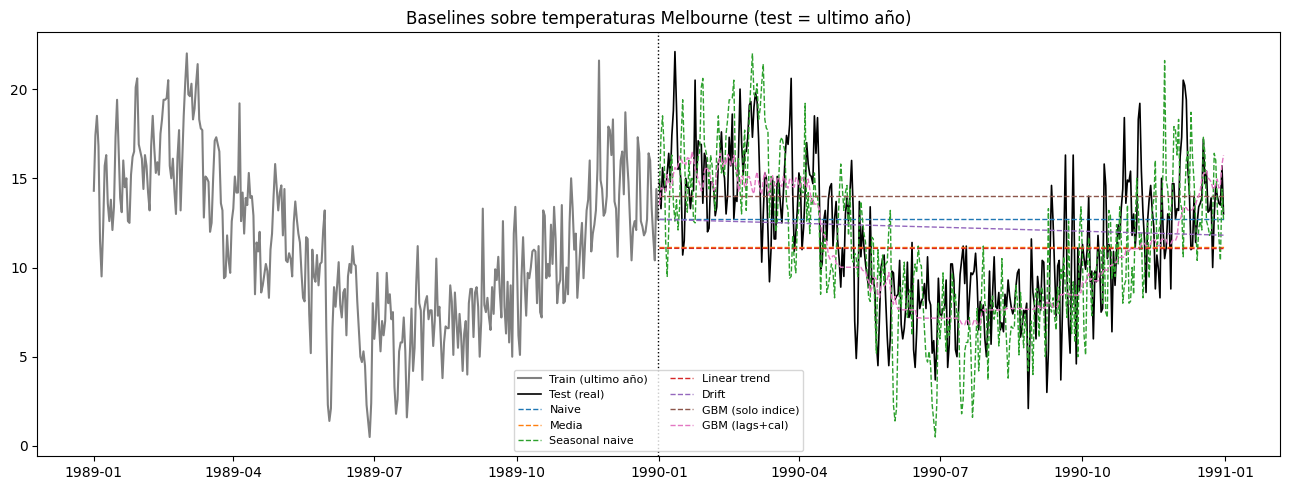

In [ ]:
plt.figure(figsize=(13, 5))
plt.plot(train.index[-365:], train.iloc[-365:], color="gray", label="Train (ultimo año)")
plt.plot(test.index, y_true, color="black", lw=1.2, label="Test (real)")
for nombre, pred in modelos.items():
    plt.plot(test.index, pred, ls="--", lw=1, label=nombre)
plt.axvline(train.index[-1], color="k", ls=":", lw=1)
plt.title("Baselines sobre temperaturas Melbourne (test = ultimo año)")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()